In [1]:
import torch
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import os
import numpy as np

from src.model import AntiArtifactModel
from src.preprocess import AudioPreprocessor

/Users/jacobmitani/anaconda3/envs/native_env/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

model = AntiArtifactModel(embed_dim=128).to(device)

weights_path = os.path.join('weights', 'train_weights3.pth')

model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()

processor = AudioPreprocessor(sample_rate=44100, n_fft=2048, hop_length=512)
print("model and preprocessor loaded and ready for evaluation")

Using device: mps
model and preprocessor loaded and ready for evaluation



Processing: Example 1 (Guitar vs Drums)


/Users/jacobmitani/anaconda3/envs/native_env/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 242, 1025]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


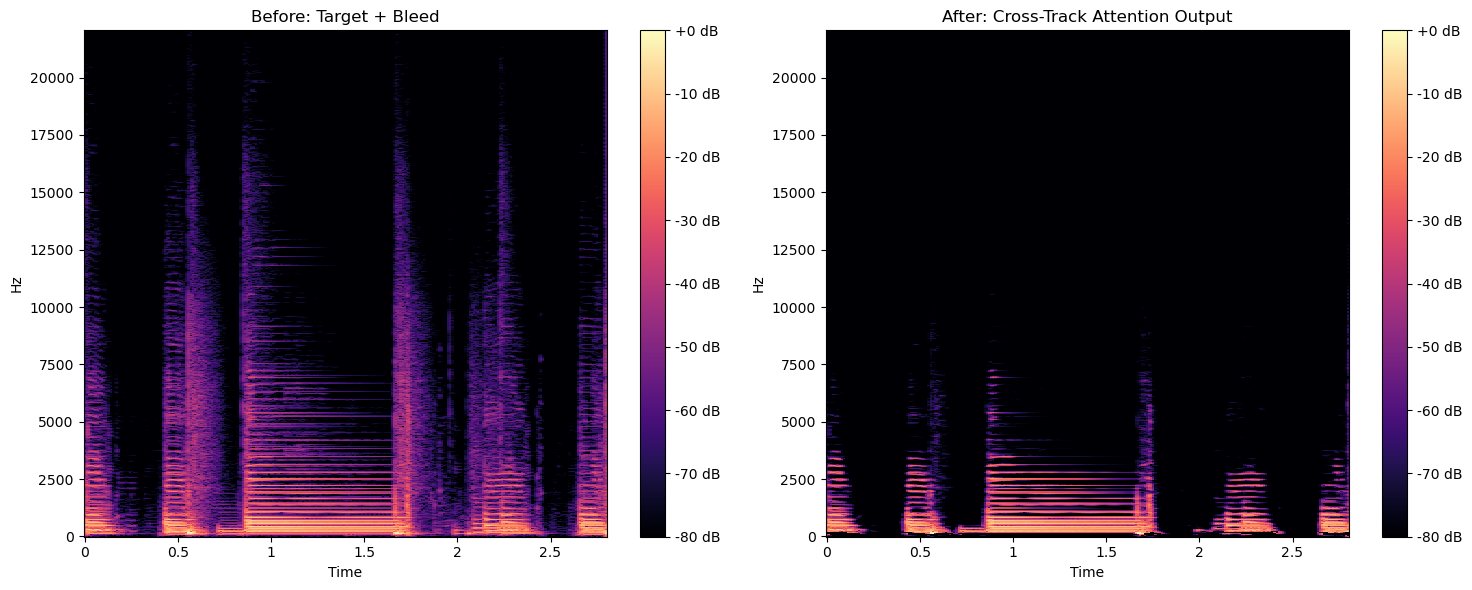

/Users/jacobmitani/DSCI410/audio_separation_project/src/preprocess.py:73: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 242, 2048]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  waveform = torch.istft(
/Users/jacobmitani/anaconda3/envs/native_env/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 242, 1025]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, 

✅ Successfully saved separated audio to: eval_data/example_one/separated_output_one.wav


Processing: Example 2 (Bass vs Drums)


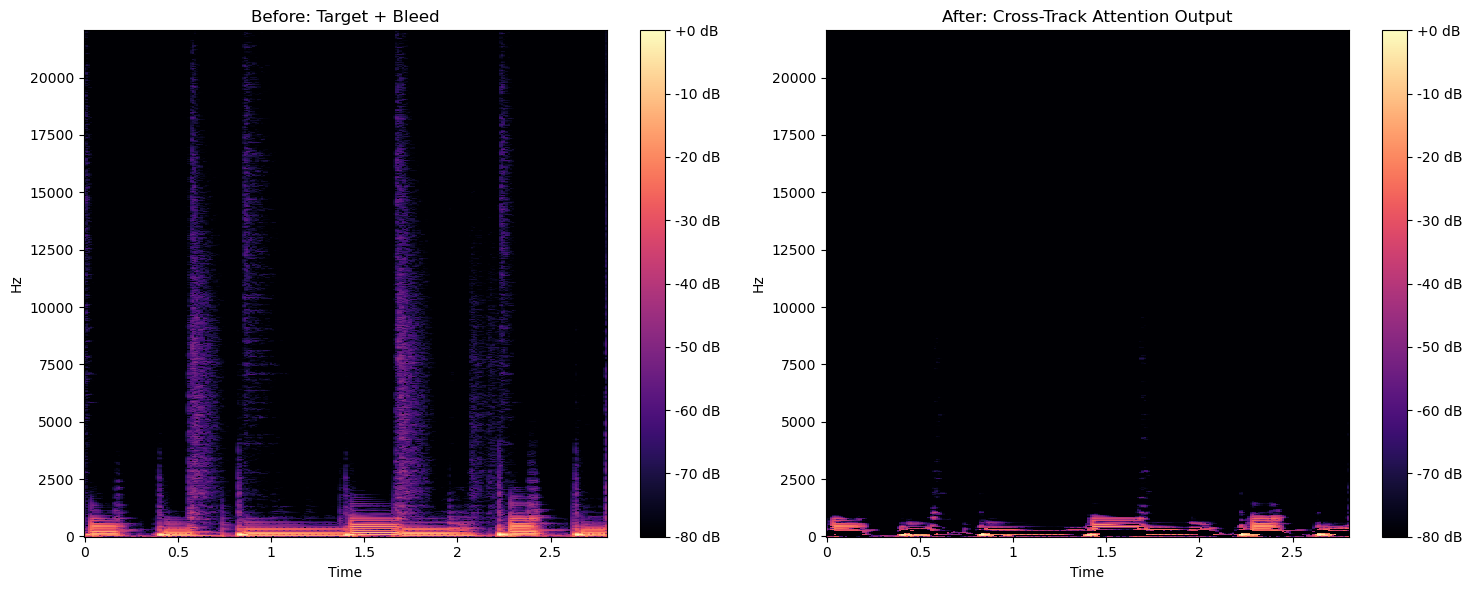

✅ Successfully saved separated audio to: eval_data/example_two/separated_output_two.wav


Processing: Example 3 (Piano vs Bass)


/Users/jacobmitani/anaconda3/envs/native_env/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 260, 1025]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


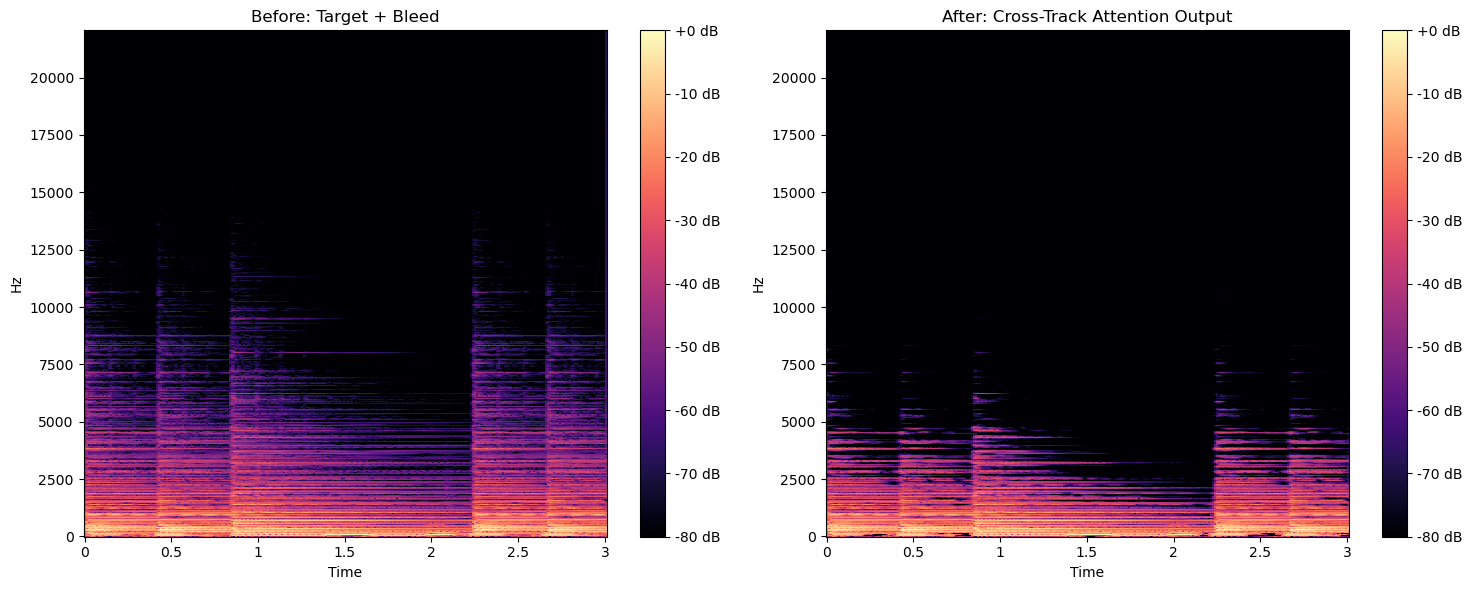

/Users/jacobmitani/DSCI410/audio_separation_project/src/preprocess.py:73: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 260, 2048]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  waveform = torch.istft(
/Users/jacobmitani/anaconda3/envs/native_env/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 259, 1025]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, 

✅ Successfully saved separated audio to: eval_data/example_three/separated_output_three.wav


Processing: Example 4 (Vocals vs Drums)


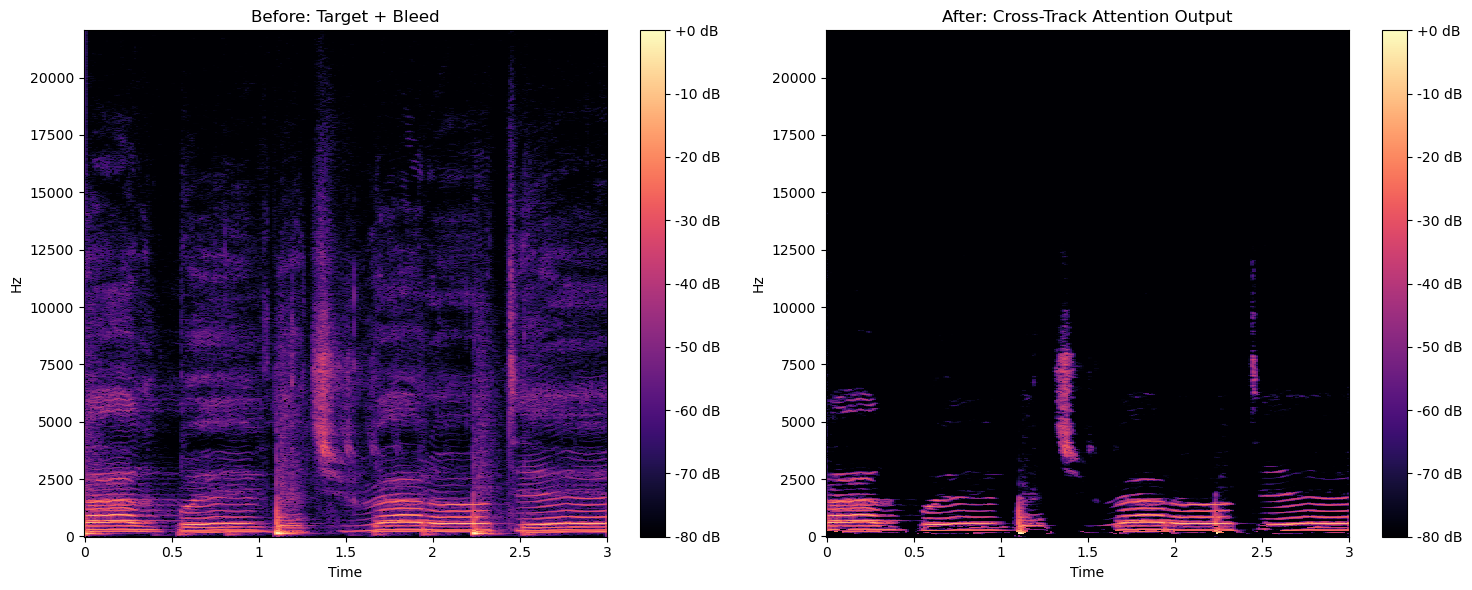

✅ Successfully saved separated audio to: eval_data/example_four/separated_output_four.wav



/Users/jacobmitani/DSCI410/audio_separation_project/src/preprocess.py:73: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 259, 2048]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  waveform = torch.istft(


In [3]:
eval_pairs = [
    {
        "name": "Example 1 (Guitar vs Drums)",
        "target": "eval_data/example_one/sample_target_one_guitar.wav", 
        "reference": "eval_data/example_one/sample_reference_one_drums.wav", 
        "output": "eval_data/example_one/separated_output_one.wav"
    },
    {
        "name": "Example 2 (Bass vs Drums)",
        "target": "eval_data/example_two/sample_target_two_bass_.wav", 
        "reference": "eval_data/example_two/sample_reference_two_drums.wav", 
        "output": "eval_data/example_two/separated_output_two.wav"
    },
    {
        "name": "Example 3 (Piano vs Bass)",
        "target": "eval_data/example_three/sample_target_three_piano.wav", 
        "reference": "eval_data/example_three/sample_reference_bass_three.wav", 
        "output": "eval_data/example_three/separated_output_three.wav"
    },
    {
        "name": "Example 4 (Vocals vs Drums)",
        "target": "eval_data/example_four/sample_target_four_vocals.wav", 
        "reference": "eval_data/example_four/sample_reference_four_drums.wav", 
        "output": "eval_data/example_four/separated_output_four.wav"
    }
]

for pair in eval_pairs:
    print(f"\n{'='*60}")
    print(f"Processing: {pair['name']}")
    print(f"{'='*60}")

 
    artifacted_wav = processor.wav_to_tensors(pair["target"])
    reference_wav = processor.wav_to_tensors(pair["reference"])


    min_len = min(artifacted_wav.shape[-1], reference_wav.shape[-1])
    artifacted_wav = artifacted_wav[:, :min_len]
    reference_wav = reference_wav[:, :min_len]

    if artifacted_wav.dim() == 3:
        artifacted_wav = artifacted_wav.squeeze(0)
    if reference_wav.dim() == 3:
        reference_wav = reference_wav.squeeze(0)


    artifacted_wav = artifacted_wav.to(device)
    reference_wav = reference_wav.to(device)

    complex_artifacted = processor.waveform_to_complex_stft(artifacted_wav)
    complex_reference = processor.waveform_to_complex_stft(reference_wav)

    mag_artifacted = torch.abs(complex_artifacted).unsqueeze(0)
    mag_reference = torch.abs(complex_reference).unsqueeze(0)

    with torch.no_grad():
        predicted_mask = model(mag_artifacted, mag_reference)
        
        predicted_mag = mag_artifacted * predicted_mask

    clean_mag = predicted_mag.squeeze().cpu().numpy()
    original_mag = mag_artifacted.squeeze().cpu().numpy()


    plt.figure(figsize=(15, 6))

    # Plot 1: Before Separation
    plt.subplot(1, 2, 1)
    librosa.display.specshow(librosa.amplitude_to_db(original_mag, ref=np.max), 
                             sr=processor.sample_rate, hop_length=processor.hop_length,
                             y_axis='hz', x_axis='time', cmap='magma')
    plt.title(f"Before: Target + Bleed")
    plt.colorbar(format='%+2.0f dB')

    # Plot 2: After Separation
    plt.subplot(1, 2, 2)
    librosa.display.specshow(librosa.amplitude_to_db(clean_mag, ref=np.max), 
                             sr=processor.sample_rate, hop_length=processor.hop_length,
                             y_axis='hz', x_axis='time', cmap='magma')
    plt.title(f"After: Cross-Track Attention Output")
    plt.colorbar(format='%+2.0f dB')

    plt.tight_layout()
    plt.show() # Renders the plot immediately before the loop continues

    # ---------------------------------------------------------
    # Reconstruction and Saving
    # ---------------------------------------------------------
    with torch.no_grad():
        clean_audio_tensor = processor.reconstruct_audio(
            complex_artifacted,
            predicted_mask
        )

    clean_audio_np = clean_audio_tensor.squeeze().cpu().numpy()

    # Anti-clipping normalization
    max_amp = np.max(np.abs(clean_audio_np))
    if max_amp > 1.0:
        print(f"Normalizing audio to prevent clipping (Max amp: {max_amp:.2f})")
        clean_audio_np = clean_audio_np / max_amp

    # Save to disk
    sf.write(pair["output"], clean_audio_np, processor.sample_rate)
    print(f"✅ Successfully saved separated audio to: {pair['output']}\n")